In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap
import joblib
import seaborn as sns

In [2]:
df = pd.read_csv('loan_detection.csv')
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())

Shape: (41188, 60)

Column Names:
 ['age', 'campaign', 'pdays', 'previous', 'no_previous_contact', 'not_working', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_no', 'default_unknown', 'default_yes', 'housing_no', 'housing_unknown', 'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'po

In [3]:
print(df.head())
print(df.info())
print(df.describe(include='all').T)

   age  campaign  pdays  previous  no_previous_contact  not_working  \
0   56         1    999         0                    1            0   
1   57         1    999         0                    1            0   
2   37         1    999         0                    1            0   
3   40         1    999         0                    1            0   
4   56         1    999         0                    1            0   

   job_admin.  job_blue-collar  job_entrepreneur  job_housemaid  ...  \
0           0                0                 0              1  ...   
1           0                0                 0              0  ...   
2           0                0                 0              0  ...   
3           1                0                 0              0  ...   
4           0                0                 0              0  ...   

   month_sep  day_of_week_fri  day_of_week_mon  day_of_week_thu  \
0          0                0                1                0   
1     

In [4]:
target_col = 'Loan_Status_label'
if target_col not in df.columns:
    print("WARNING: update target_col variable to the correct target column name from df.columns above.")
else:
    print("Target distribution:")
    print(df[target_col].value_counts())
    print("Proportions:")
    print(df[target_col].value_counts(normalize=True))

Target distribution:
Loan_Status_label
0    36548
1     4640
Name: count, dtype: int64
Proportions:
Loan_Status_label
0    0.887346
1    0.112654
Name: proportion, dtype: float64


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing>0]
missing
print("Duplicates:", df.duplicated().sum())

Duplicates: 2417


In [6]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
if target_col in num_cols: num_cols.remove(target_col)
if target_col in cat_cols: cat_cols.remove(target_col)
print("Numeric:", num_cols)
print("Categorical:", cat_cols)


Numeric: ['age', 'campaign', 'pdays', 'previous', 'no_previous_contact', 'not_working', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_no', 'default_unknown', 'default_yes', 'housing_no', 'housing_unknown', 'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_failure', 'poutcome

In [7]:
num_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [8]:
X = df.drop(columns=[target_col])
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(32950, 59) (8238, 59)


In [9]:
pipe_lr = Pipeline(steps=[('pre', preprocessor),
                          ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_proba_lr = pipe_lr.predict_proba(X_test)[:,1]
print("Logistic Regression - ROC AUC:", roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression - ROC AUC: 0.7654394075192226
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      7310
           1       0.30      0.59      0.39       928

    accuracy                           0.80      8238
   macro avg       0.62      0.71      0.64      8238
weighted avg       0.87      0.80      0.82      8238



In [10]:
pipe_rf = Pipeline(steps=[('pre', preprocessor),
                          ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))])
pipe_rf.fit(X_train, y_train)
y_proba_rf = pipe_rf.predict_proba(X_test)[:,1]
y_pred_rf = pipe_rf.predict(X_test)
print("Random Forest - ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest - ROC AUC: 0.7510386692768526
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.52      0.25      0.34       928

    accuracy                           0.89      8238
   macro avg       0.71      0.61      0.64      8238
weighted avg       0.87      0.89      0.87      8238



In [11]:
pos = sum(y_train==1)
neg = sum(y_train==0)
scale_pos_weight = neg / pos if pos>0 else 1
pipe_xgb = Pipeline(steps=[('pre', preprocessor),
                           ('clf', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                                     scale_pos_weight=scale_pos_weight, random_state=42))])
pipe_xgb.fit(X_train, y_train)
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:,1]
y_pred_xgb = pipe_xgb.predict(X_test)
print("XGBoost - ROC AUC:", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost - ROC AUC: 0.7575703747818294
              precision    recall  f1-score   support

           0       0.94      0.85      0.89      7310
           1       0.32      0.55      0.40       928

    accuracy                           0.82      8238
   macro avg       0.63      0.70      0.65      8238
weighted avg       0.87      0.82      0.84      8238



C:\Users\jsabi\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [23:39:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [12]:
param_dist = {
    'clf__n_estimators': [100, 200, 400],
    'clf__max_depth': [None, 6, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4]
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search_rf = RandomizedSearchCV(pipe_rf, param_distributions=param_dist, n_iter=20, cv=skf, scoring='roc_auc', n_jobs=-1, random_state=42)
search_rf.fit(X_train, y_train)
print("Best RF params:", search_rf.best_params_)
print("Best RF cv ROC AUC:", search_rf.best_score_)
best_rf = search_rf.best_estimator_

param_dist_xgb = {
    'clf__n_estimators': [100,200,400],
    'clf__max_depth': [3,5,7,10],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.6, 0.8, 1],
    'clf__colsample_bytree': [0.6, 0.8, 1],
    'clf__reg_alpha': [0, 0.01, 0.1],
}
search_xgb = RandomizedSearchCV(pipe_xgb,param_distributions=param_dist_xgb, n_iter=30, cv=skf, scoring='roc_auc', n_jobs=-1, random_state=42)
search_xgb.fit(X_train, y_train)
print("Best XGB params:", search_xgb.best_params_)
print("Best XGB cv ROC AUC:", search_xgb.best_score_)
best_xgb = search_xgb.best_estimator_

Best RF params: {'clf__n_estimators': 200, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_depth': 10}
Best RF cv ROC AUC: 0.7711428915645596


C:\Users\jsabi\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [23:41:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB params: {'clf__subsample': 0.8, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 400, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.6}
Best XGB cv ROC AUC: 0.7723615268732003


Best RF - ROC AUC: 0.7791, PR AUC (avg precision): 0.4340
              precision    recall  f1-score   support

           0       0.94      0.87      0.91      7310
           1       0.36      0.57      0.44       928

    accuracy                           0.84      8238
   macro avg       0.65      0.72      0.67      8238
weighted avg       0.88      0.84      0.85      8238



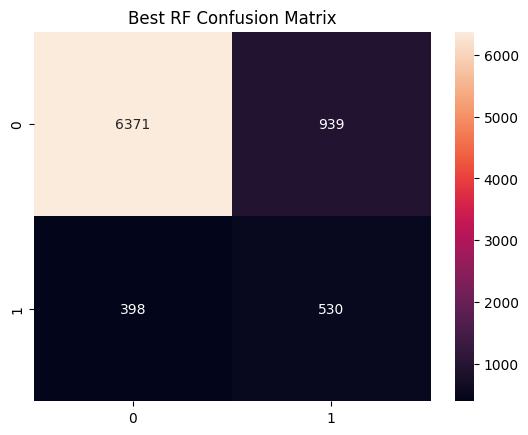

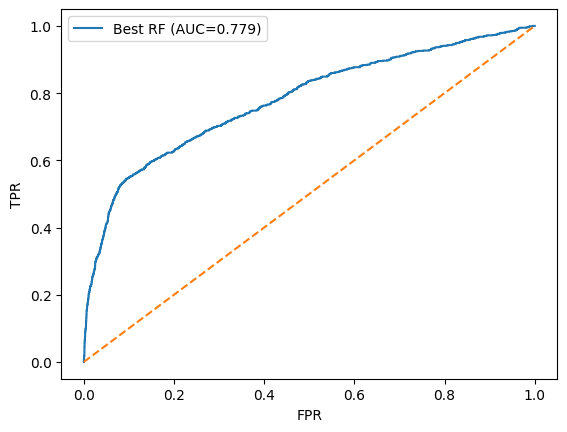

Best XGB - ROC AUC: 0.7846, PR AUC (avg precision): 0.4441
              precision    recall  f1-score   support

           0       0.94      0.89      0.91      7310
           1       0.39      0.57      0.46       928

    accuracy                           0.85      8238
   macro avg       0.66      0.73      0.69      8238
weighted avg       0.88      0.85      0.86      8238



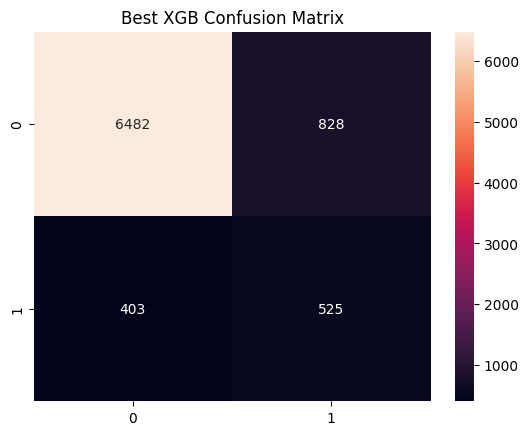

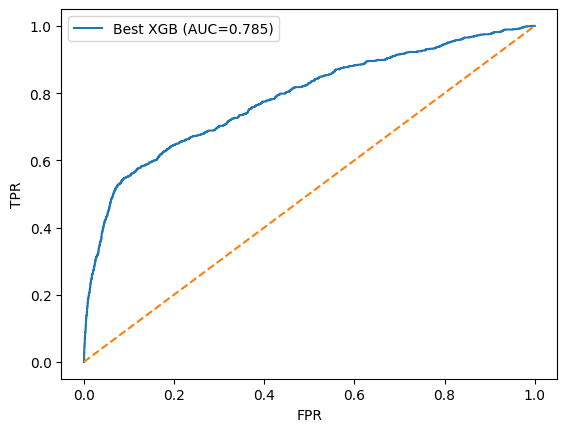

Logistic Regression (baseline) - ROC AUC: 0.7654, PR AUC (avg precision): 0.4166
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      7310
           1       0.30      0.59      0.39       928

    accuracy                           0.80      8238
   macro avg       0.62      0.71      0.64      8238
weighted avg       0.87      0.80      0.82      8238



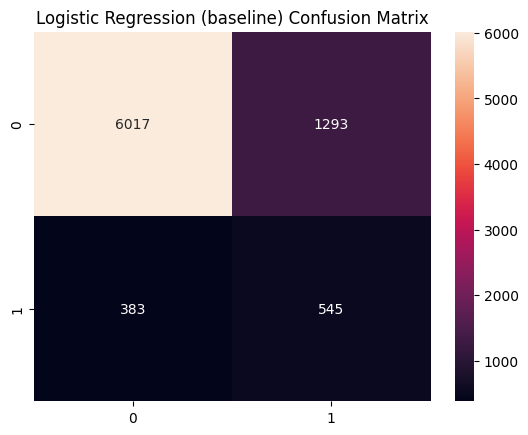

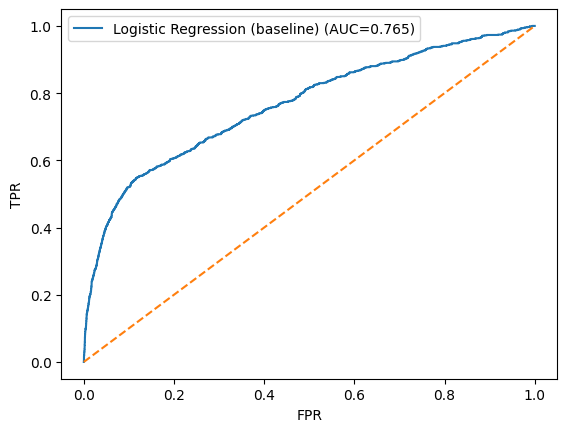

In [13]:
def evaluate_model(model, X_test, y_test, name='Model'):
    y_proba = model.predict_proba(X_test)[:,1]
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    print(f"{name} - ROC AUC: {auc:.4f}, PR AUC (avg precision): {ap:.4f}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'{name} Confusion Matrix')
    plt.show()
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.show()
    
# Evaluate best models
evaluate_model(best_rf, X_test, y_test, 'Best RF')
evaluate_model(best_xgb, X_test, y_test, 'Best XGB')
evaluate_model(pipe_lr, X_test, y_test, 'Logistic Regression (baseline)')

Total features after preprocessing: 59


 99%|===================| 8186/8238 [01:15<00:00]        

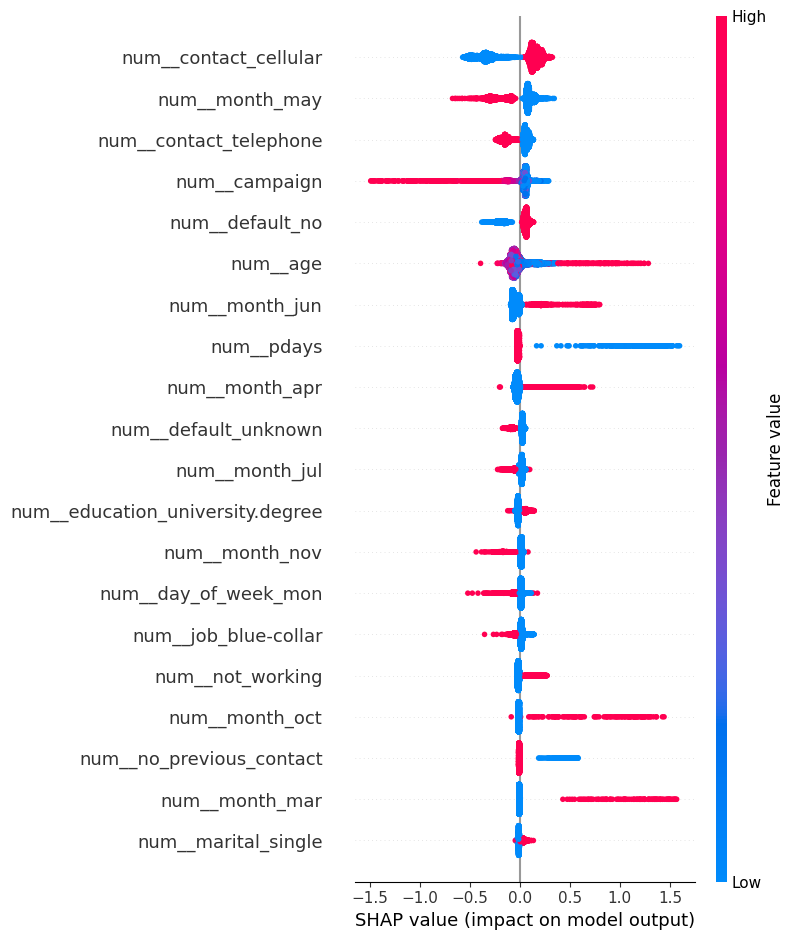

In [14]:
fitted_preprocessor = best_xgb.named_steps['pre']


X_train_pre = fitted_preprocessor.transform(X_train)
X_test_pre = fitted_preprocessor.transform(X_test)

#
feature_names = fitted_preprocessor.get_feature_names_out()
print("Total features after preprocessing:", len(feature_names))

explainer = shap.Explainer(best_xgb.named_steps['clf'], X_train_pre)


shap_values = explainer(X_test_pre)
shap.summary_plot(shap_values, X_test_pre, feature_names=feature_names)


In [15]:
joblib.dump(best_xgb, 'best_xgb_credit_risk_model.joblib')

joblib.dump(preprocessor, 'preprocessor.joblib')

['preprocessor.joblib']